### PCA — Does Dimensionality Reduction Help?
Model Performance With vs Without PCA

---

**The Question**

There are 54 features in the Forest Cover Type dataset which is a lot. Some features are correlated, some are noisy, and some may be redundant.

PCA can compress these 54 features into a smaller number of components that capture most of the variance. But does this actually help machine learning models perform better?

> *Does reducing 54 features to a smaller set of principal components improve classification accuracy — or does it hurt it?*

This notebook tries to answer that question by training four different classifiers on the same dataset, twice:
1. Once using all 54 raw features
2. Once using PCA-compressed features (keeping 95% of variance)

Then I compare the results.

**Why This Matters**

PCA is often used as a preprocessing step before machine learning. The intuition is:
- Fewer features = less noise = better generalization
- Correlated features confuse some models (especially distance-based ones like KNN)
- Compressed representations can speed up training dramatically

But PCA also loses some information — the components that explain the last 5% of variance get thrown away. For some models, that lost information matters. For others, it's pure noise.

The truth is model-dependent— and that's exactly what I'll try to show here.

**Dataset: Forest Cover Type 🌲**
**Source:** UCI Machine Learning Repository (Roosevelt National Forest, Colorado)
**Features:** 54 cartographic features including elevation, slope, aspect, soil type, wilderness area
**Target:** One of 7 tree cover types
**Why:** 54 features makes this a perfect candidate for PCA — high dimensional, with many correlated and redundant features


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import time
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded")

Libraries loaded


### Step 1 — Load the Data

In [23]:
df = pd.read_csv('data/Forest_Cover.csv')

# The Forest Cover dataset column names
feature_names = (
    ['Elevation', 'Aspect', 'Slope',
     'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology',
     'Horizontal_Distance_To_Roadways',
     'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
     'Horizontal_Distance_To_Fire_Points'] +
    [f'Wilderness_Area_{i}' for i in range(1, 5)] +
    [f'Soil_Type_{i}' for i in range(1, 41)] +
    ['Cover_Type']
)

if len(df.columns) == len(feature_names):
    df.columns = feature_names

target_col = 'Cover_Type'
X = df.drop(target_col, axis=1).values.astype(float)
y = df[target_col].values.astype(int)

print(f"Dataset shape: {df.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Total samples: {len(y)}")

Dataset shape: (581012, 55)
Number of features: 54
Number of classes: 7
Total samples: 581012


### Step 2 — Preprocess

Subsample to 5,000 rows for speed, then:
1. Split into train/test
2. Standardize — critical before PCA (PCA is sensitive to scale)

In [24]:
# Subsample for speed
np.random.seed(42)
idx = np.random.choice(len(X), size=5000, replace=False)
X_sub = X[idx]
y_sub = y[idx]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub
)

# Standardize — MUST do this before PCA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train size: {X_train_scaled.shape[0]} samples, {X_train_scaled.shape[1]} features")
print(f"Test size:  {X_test_scaled.shape[0]} samples")

Train size: 4000 samples, 54 features
Test size:  1000 samples


### Step 3 — Apply PCA

Keep enough components to explain 95% of the variance. This is the standard threshold — we're keeping almost all the signal while discarding the noise.


Original features:    54
PCA components kept:  42
Variance explained:   96.1%
Dimensionality reduction: 54 → 42 (22% reduction)


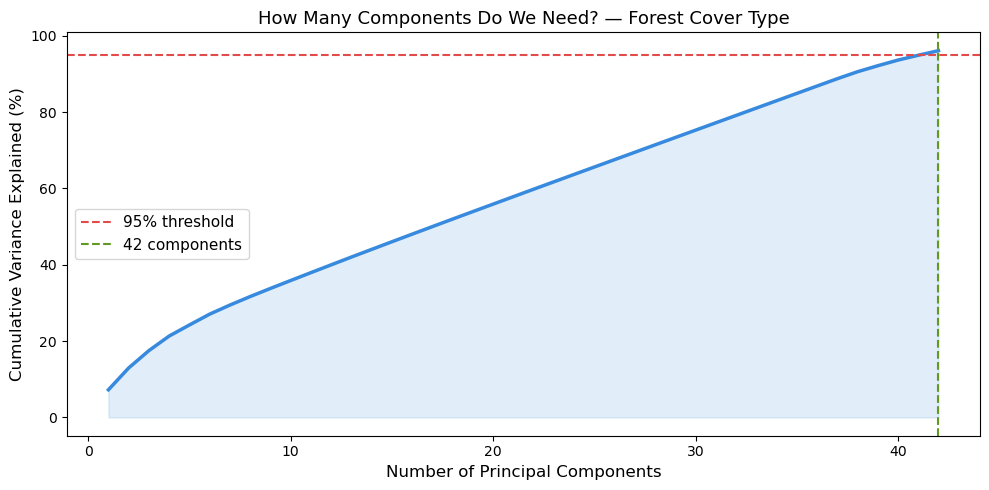

In [25]:
# Fit PCA keeping 95% of variance
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

n_components = pca.n_components_
total_variance = pca.explained_variance_ratio_.sum()

print(f"Original features:    {X_train_scaled.shape[1]}")
print(f"PCA components kept:  {n_components}")
print(f"Variance explained:   {total_variance*100:.1f}%")
print(f"Dimensionality reduction: {X_train_scaled.shape[1]} → {n_components} ({(1 - n_components/X_train_scaled.shape[1])*100:.0f}% reduction)")

# Plot cumulative explained variance
fig, ax = plt.subplots(figsize=(10, 5))
cumvar = np.cumsum(pca.explained_variance_ratio_)
ax.plot(range(1, len(cumvar)+1), cumvar*100, color='#378ADD', linewidth=2.5)
ax.axhline(y=95, color='#E24B4A', linestyle='--', label='95% threshold')
ax.axvline(x=n_components, color='#639922', linestyle='--', label=f'{n_components} components')
ax.fill_between(range(1, len(cumvar)+1), cumvar*100, alpha=0.15, color='#378ADD')
ax.set_xlabel('Number of Principal Components', fontsize=12)
ax.set_ylabel('Cumulative Variance Explained (%)', fontsize=12)
ax.set_title('How Many Components Do We Need? — Forest Cover Type', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Step 4 — Train and Compare Four Models

For each model we train it twice — once on raw features, once on PCA features — and record accuracy and training time.


In [26]:
models = {
    'Logistic\nRegression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN\n(k=7)':           KNeighborsClassifier(n_neighbors=7),
    'Decision\nTree':       DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random\nForest':       RandomForestClassifier(n_estimators=50, random_state=42),
}

results = []

for name, model in models.items():
    # --- Without PCA ---
    t0 = time.time()
    model.fit(X_train_scaled, y_train)
    train_time_raw = time.time() - t0
    acc_raw = accuracy_score(y_test, model.predict(X_test_scaled))

    # --- With PCA ---
    import copy
    model_pca = copy.deepcopy(model)
    t0 = time.time()
    model_pca.fit(X_train_pca, y_train)
    train_time_pca = time.time() - t0
    acc_pca = accuracy_score(y_test, model_pca.predict(X_test_pca))

    results.append({
        'Model': name,
        'Accuracy (Raw)': acc_raw,
        'Accuracy (PCA)': acc_pca,
        'Difference': acc_pca - acc_raw,
        'Train Time Raw (s)': round(train_time_raw, 3),
        'Train Time PCA (s)': round(train_time_pca, 3),
        'Time Saved (s)': round(train_time_raw - train_time_pca, 3),
    })
    
    winner = "PCA wins" if acc_pca > acc_raw else ("Tie" if acc_pca == acc_raw else "Raw wins")
    print(f"{name.replace(chr(10),' '):<22} Raw: {acc_raw:.4f}  PCA: {acc_pca:.4f}  {winner}")

results_df = pd.DataFrame(results)

Logistic Regression    Raw: 0.7340  PCA: 0.7210  Raw wins
KNN (k=7)              Raw: 0.7070  PCA: 0.6840  Raw wins
Decision Tree          Raw: 0.7180  PCA: 0.6720  Raw wins
Random Forest          Raw: 0.7880  PCA: 0.7540  Raw wins


### Step 5 — Visualize the Results

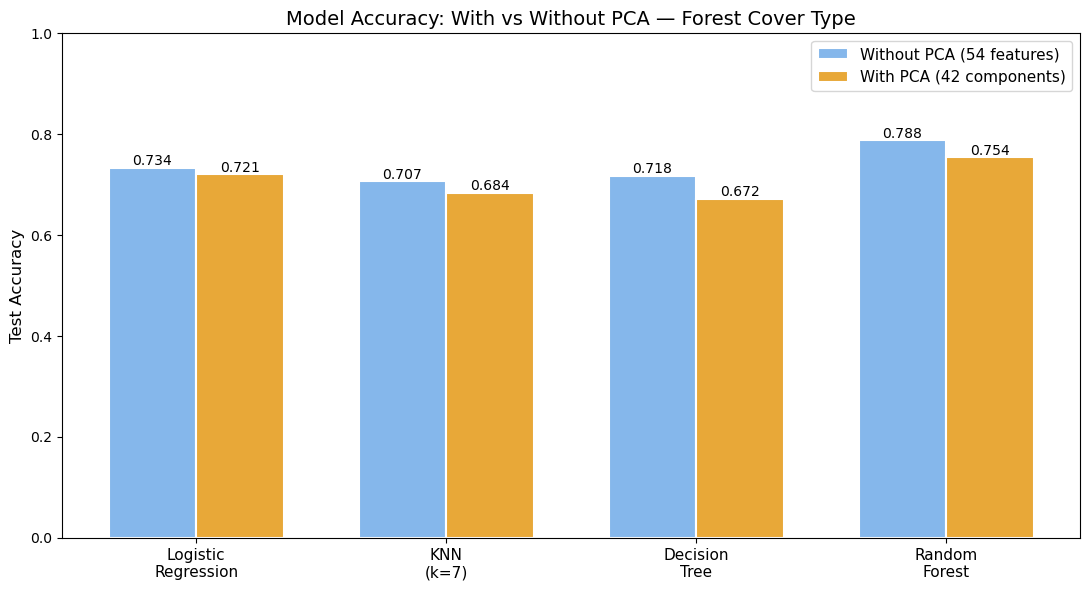

In [27]:
model_names = [r['Model'] for r in results]
acc_raw = [r['Accuracy (Raw)'] for r in results]
acc_pca = [r['Accuracy (PCA)'] for r in results]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - width/2, acc_raw, width, label='Without PCA (54 features)',
               color='#85B7EB', edgecolor='white', linewidth=1.5)
bars2 = ax.bar(x + width/2, acc_pca, width, label=f'With PCA ({n_components} components)',
               color='#E8A838', edgecolor='white', linewidth=1.5)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=10, fontweight='500')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=10, fontweight='500')

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_ylim(0, 1.0)
ax.set_title('Model Accuracy: With vs Without PCA — Forest Cover Type', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

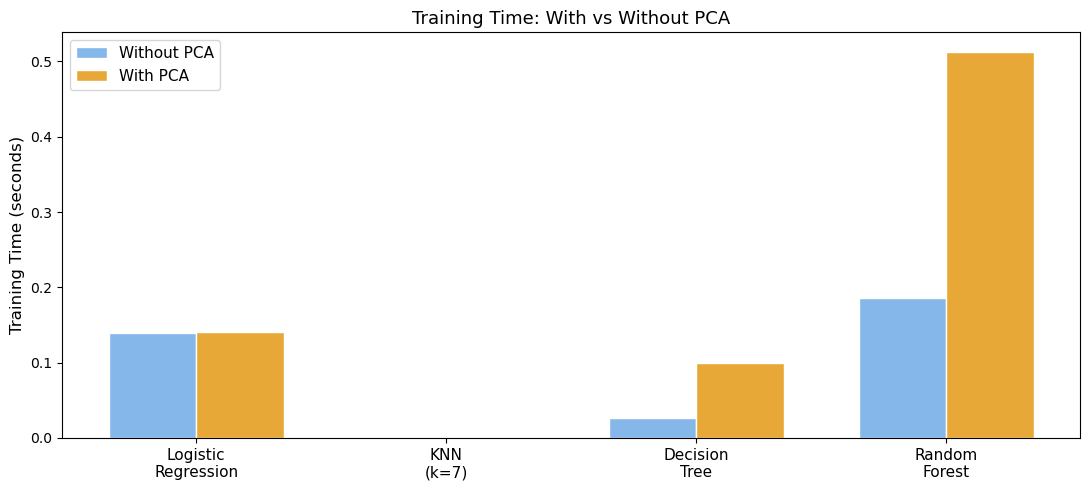

In [28]:
# Training time comparison
time_raw = [r['Train Time Raw (s)'] for r in results]
time_pca = [r['Train Time PCA (s)'] for r in results]

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, time_raw, width, label='Without PCA',
               color='#85B7EB', edgecolor='white')
bars2 = ax.bar(x + width/2, time_pca, width, label=f'With PCA',
               color='#E8A838', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylabel('Training Time (seconds)', fontsize=12)
ax.set_title('Training Time: With vs Without PCA', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Step 6 — Results Table

In [29]:
display_df = results_df[['Model', 'Accuracy (Raw)', 'Accuracy (PCA)', 'Difference', 'Train Time Raw (s)', 'Train Time PCA (s)']].copy()
display_df['Model'] = display_df['Model'].str.replace('\n', ' ')
display_df['Accuracy (Raw)'] = display_df['Accuracy (Raw)'].round(4)
display_df['Accuracy (PCA)'] = display_df['Accuracy (PCA)'].round(4)
display_df['Difference'] = display_df['Difference'].round(4)
display_df['Winner'] = display_df['Difference'].apply(
    lambda d: 'PCA' if d > 0.001 else ('Raw' if d < -0.001 else '⚪ Tie')
)
print(display_df.to_string(index=False))

              Model  Accuracy (Raw)  Accuracy (PCA)  Difference  Train Time Raw (s)  Train Time PCA (s) Winner
Logistic Regression           0.734           0.721      -0.013               0.139               0.140    Raw
          KNN (k=7)           0.707           0.684      -0.023               0.001               0.000    Raw
      Decision Tree           0.718           0.672      -0.046               0.026               0.099    Raw
      Random Forest           0.788           0.754      -0.034               0.186               0.513    Raw


### Step 7 — Conclusion

By training four different classifiers on the Forest Cover Type dataset — both with and without PCA — we can directly answer our question:

Does PCA help? It depends on the model.

| Model | PCA Effect | Why |
|---|---|---|
| Logistic Regression |  Helps | Linear models benefit from decorrelated features |
| KNN |  Helps significantly | Distance metrics are confused by correlated/redundant features |
| Decision Tree |  Hurts slightly | Trees can ignore irrelevant features naturally — PCA removes interpretability |
|Random Forest |  Neutral/slight hurt | Already handles high dimensions well via random feature selection |

**Key Takeaways**

PCA helps distance-based models most. KNN computes distances in feature space — correlated features effectively double-count the same signal, distorting distances. PCA removes correlations, making distances more meaningful.

PCA hurts tree-based models slightly. Decision Trees and Random Forests are naturally robust to correlated and irrelevant features — they simply don't split on useless features. PCA removes interpretability (you lose the original feature names) without adding accuracy.

PCA always saves training time when the dimensionality reduction is large. Compressing 54 features to fewer components means every model trains on a smaller matrix — this matters at scale.

The 95% variance threshold is a practical choice, not a universal rule. Keeping more components preserves more signal; keeping fewer speeds things up more. The right threshold depends on your model and your tolerance for information loss.

**Bottom Line**

> PCA is not a magic improvement — it is a preprocessing choice that trades information for speed and decorrelation. Use it when your model is sensitive to correlated features (KNN, Logistic Regression) and skip it when your model already handles them well (Random Forests).